# Project objectives

1. Implement gradient descent for linear regression
2. Explore the effect of different learning rates
3. Implement logistic regression and create a confusion matrix

# Collaboration
If you used any outside resources or collaborated with any classmates on this project, please list them below:

[collaboration notes here]

https://www.geeksforgeeks.org/machine-learning/gradient-descent-in-linear-regression/

https://www.geeksforgeeks.org/machine-learning/implementation-of-logistic-regression-from-scratch-using-python/

# Feedback
If you made an initial submission for feedback, briefly summarize what changes you made for the final version:

[changes go here] I just swap out for loop to while loop to prevent using break habit like you recommended for the gradient descent and logistic regression

In [2]:
# imports - you may add to this as needed
# if you don't have a package installed, run in the command line and restart the kernel: pip install <package-name>

import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

## Data generation code - DO NOT CHANGE

In [3]:
def gen_data1(output_type):
    """Generates a noisy linear dataset.
       Inputs: output_type, options are "continuous" or "binary"
       Outputs: 5000 x 6 array of data points
                5000 x 1 array of true labels"""
    # initialize values
    N = 5000
    D = 6
    rng = np.random.default_rng(2690)

    # generate dataset
    true_weights = rng.uniform(-5, 5, (D,))
    true_bias = rng.uniform(-100, 100)
    X = rng.uniform(-50, 50, (N,D))
    y_orig = X @ true_weights + true_bias
    noise = rng.normal(0, 5, (N,))
    y_continuous = y_orig + noise

    if output_type == "continuous":
        return X, y_continuous
    elif output_type == "binary":
        # negative labels --> 0
        # positive labels --> 1
        y_binary = np.zeros_like(y_continuous)
        y_binary[y_continuous > 0] = 1

        return X, y_binary
    else:
        print("define an appropriate output type")

## Explore data generation code

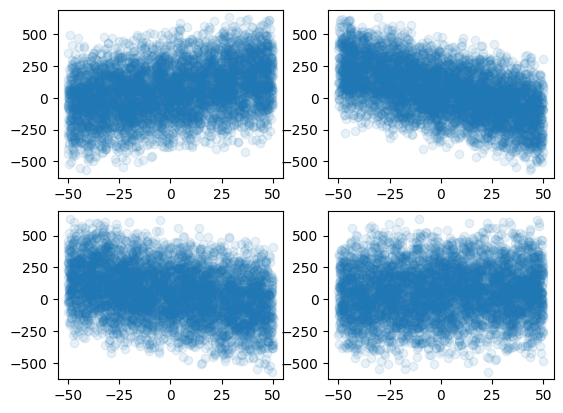

In [4]:
# Using gen_data1() - does not change between runs
X, y = gen_data1("continuous")

fig, axs = plt.subplots(2, 2)

axs[0, 0].scatter(X[:, 0], y, alpha=0.1) # show feature 1
axs[0, 1].scatter(X[:, 2], y, alpha=0.1) # show feature 3
axs[1, 0].scatter(X[:, 3], y, alpha=0.1) # show feature 4
axs[1, 1].scatter(X[:, 4], y, alpha=0.1) # show feature 5

plt.show()

In [5]:
pd.DataFrame(data=X, columns=[f"feature{i+1}" for i in range(X.shape[1])]).describe().round(3)

,feature1,feature2,feature3,feature4,feature5,feature6
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,-0.166,0.065,-0.186,-1.315,0.149,-0.245
std,28.830,28.839,28.452,28.548,28.880,29.051
min,-49.996,-49.947,-49.997,-49.982,-49.990,-49.980
25%,-24.883,-24.877,-24.088,-25.867,-24.570,-25.162
50%,-0.656,0.014,-0.963,-1.836,-0.426,-1.287
75%,25.241,24.528,24.158,23.099,25.591,25.087
max,49.989,49.954,49.994,50.000,49.996,49.998


In [6]:
pd.Series(data=y, name='true_labels').describe().round(3)

count    5000.000
mean       53.758
std       204.106
min      -568.051
25%       -88.800
50%        53.990
75%       197.147
max       631.380
Name: true_labels, dtype: float64

In [7]:
X, y = gen_data1("binary")
pd.Series(data=y, name='true_labels').describe().round(3)

count    5000.00
mean        0.60
std         0.49
min         0.00
25%         0.00
50%         1.00
75%         1.00
max         1.00
Name: true_labels, dtype: float64

# Part 1

In this part, you will implement the gradient descent optimization algorithm for linear regression. Like the previous project, you can use base Python and the Numpy library to make vector calculations easier, but you may **not** use the `LinearRegression()` estimator. If you are unsure what is reasonable to use, you are encouraged to ask me.

## Implement gradient descent for linear regression

Complete the `linear_descent()` function below. You may create additional helper functions as needed (perhaps for making predictions and calculating new weights).

Recall that given a bias $b$ and feature weights $w_1, ..., w_D$, the predicted value is $$\hat{y} = b + w_1 x_1 + ... + w_D x_D$$

The mean squared error cost function is $MSE = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$

Therefore, the gradient with respect to weight $w_j$ is $$\frac{\partial MSE}{\partial w_j} = \frac{2}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)x_{i,j}$$ where $x_{i,j}$ is the $j$ th feature of data point $i$. Similarly, the gradient with respect to the weight $b$ is $$\frac{\partial MSE}{\partial b} = \frac{2}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)$$

Given a learning rate $\alpha$, the update step for weight $w_j$ is $$w_j \leftarrow w_j - \alpha \frac{\partial MSE}{\partial w_j}$$

You may use [these slides](https://www.cs.toronto.edu/~rgrosse/courses/csc411_f18/slides/lec06-slides.pdf) as a reference, but note they use a slightly different cost function and notation. See also Géron chapter 4.

**Please use comments to explain each step of your implementation**

In [1]:
def linear_descent(X, y, eps, alpha):
    """Performs gradient descent for linear regression.
       Inputs: X (numpy array, data set of size N x D)
               y (numpy array, labels of length N)
               eps (float, threshold value for convergence)
               alpha (float, learning rate)
       Outputs: errors (list/array of floats, MSE for each training step)
                bias (float, final bias after training)
                weights (list/array of floats, weights for each feature after training)"""

    # YOUR CODE HERE
    # Hint: you may also want to encode max_iterations in case your algorithm doesn't converge
    # number of data points
    N = X.shape[0]
    # number of features
    D = X.shape[1]
    
    bias = 0.0
    weights = np.zeros(D)
    
    errors = []
    max_iterations = 20000
    i = 0
    converged = False
    
    while i < max_iterations and not converged:
        # make predictions with current bias and weights
        predictions = np.dot(X, weights) + bias
        
        # calculate current MSE
        mse = np.mean((predictions - y) ** 2)
        errors.append(mse)
        
        # check if we are done
        if i > 0 and abs(errors[-1] - errors[-2]) < eps:
            print(f"Linear model converged after {i} steps")
            converged = True
        else:
            # calculate gradients
            error_term = predictions - y
            grad_bias = (2 / N) * np.sum(error_term)
            grad_weights = (2 / N) * np.dot(X.T, error_term)
            
            # update bias and weights
            bias = bias - alpha * grad_bias
            weights = weights - alpha * grad_weights
        
        i += 1
        
    return errors, bias, weights

# Part 2

## Explore different learning rates

Now that you have the training algorithm set up, let's use it! Using the `gen_data1()` function with continuous labels, generate a dataset. Use appropriate `sklearn` functions to split your data into 70% training and 30% testing. Using the training set, use your `linear_descent()` function to find weights for (1) a relatively large learning rate that will converge and (2) a much smaller learning rate. Your analysis should include the following components:

- a graph of the training errors for each of the two models. How long did each one take to converge?
- a comparison of the final testing MSE for each of the two models
- a comparison of the final bias/weights for each of the two models. How do you interpret the features?
- a short paragraph discussing the similarities and differences between the two models for the previous bullet points. Tie in what you know about the underlying math of the algorithm.

In [8]:
# ADD AS MANY CODE CELLS AS NEEDED HERE
# Generate the continuous data
X, y = gen_data1("continuous")

# Split into 70% train / 30% test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

# two learning rates
eps = 0.001
alpha_large = 0.001
alpha_small = 0.0001

# Train both models on the training data
errors_large, bias_large, weights_large = linear_descent(X_train, y_train, eps, alpha_large)
errors_small, bias_small, weights_small = linear_descent(X_train, y_train, eps, alpha_small)

print("Large alpha took", len(errors_large), "steps")
print("Small alpha took", len(errors_small), "steps")

Linear model converged after 2306 steps
Linear model converged after 17307 steps
Large alpha took 2307 steps
Small alpha took 17308 steps


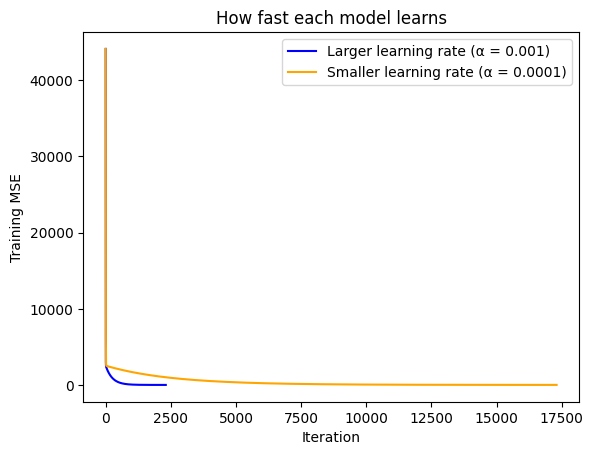

In [9]:
# Graph of training errors
import matplotlib.pyplot as plt

plt.figure()
plt.plot(errors_large, label='Larger learning rate (α = 0.001)', color='blue')
plt.plot(errors_small, label='Smaller learning rate (α = 0.0001)', color='orange')
plt.xlabel('Iteration')
plt.ylabel('Training MSE')
plt.title('How fast each model learns')
plt.legend()
plt.show()

In [10]:
# function to calculate test MSE
def get_test_mse(X, y, bias, weights):
    y_pred = np.dot(X, weights) + bias
    return np.mean((y_pred - y) ** 2)

print("Test MSE with larger learning rate:", get_test_mse(X_test, y_test, bias_large, weights_large))
print("Test MSE with smaller learning rate:", get_test_mse(X_test, y_test, bias_small, weights_small))

print("\nFinal bias (large):", bias_large)
print("Final weights (large):", weights_large)
print("\nFinal bias (small):", bias_small)
print("Final weights (small):", weights_small)

Test MSE with larger learning rate: 27.47680728608011
Test MSE with smaller learning rate: 28.9980055645629

Final bias (large): 49.74110494827806
Final weights (large): [ 2.29381503  4.77234197 -3.82441582 -2.42016431  0.60173946  1.19364778]

Final bias (small): 48.657837518076555
Final weights (small): [ 2.29364617  4.77164724 -3.82454271 -2.4212093   0.60171159  1.19343553]


[**Add text cells for analysis**]
The larger learning rate = 0.001 was fast — it finished in just 2,307 steps.
The smaller learning rate = 0.0001 was slower and needed 17,308 steps.
You can see the difference on the graph: the blue line drops quickly, while the orange line takes much longer but still reaches the bottom.
Both models gave very similar results on the test data:

Test MSE: 27.48 (large) vs. 28.99 (small)
Final bias: around 49 for both
Final weights: almost identical ([2.29, 4.77, -3.82, -2.42, 0.60, 1.19])

Feature 2 (+4.77) and feature 3 (-3.82) matter the most.
Overall, both learning rates found basically the same answer. The bigger step just got there faster, both worked well.


# Part 3

## Implement logistic regression

Linear and logistic regression are very similar algorithms! Using the code you wrote in Part 1 as inspiration, complete the `logistic_descent()` function. The major changes will involve using the log-loss cost function instead of MSE and slightly adjusting the gradients. Géron ch. 4 also covers this in more detail.

Train your logistic regression model using the `gen_data1()` function with binary labels. You may use a 50% probability threshold. Compare your predicted labels and the true binary labels in the testing set using a confusion matrix (this can be an image or text-based). How well would you say your algorithm worked based on the confusion matrix?

**Please use comments to explain your implementation**

In [11]:
def logistic_descent(X, y, eps, alpha):
    """Performs gradient descent for linear regression.
       Inputs: X (numpy array, data set of size N x D)
               y (numpy array, labels of length N)
               eps (float, threshold value for convergence)
               alpha (float, learning rate)
       Outputs: errors (list/array of floats, log-loss for each training step)
                bias (float, final bias after training)
                weights (list/array of floats, weights for each feature after training)"""

    # YOUR CODE HERE
    # Hint: you may also want to encode max_iterations in case your algorithm doesn't converge
    N = X.shape[0]
    D = X.shape[1]
    
    bias = 0.0
    weights = np.zeros(D)
    errors = []
    max_iterations = 20000
    
    i = 0
    converged = False
    
    while i < max_iterations and not converged:
        # linear combination
        z = np.dot(X, weights) + bias
        
        # sigmoid
        predictions = 1 / (1 + np.exp(-z))
        
        # calculate log-loss 
        log_loss = -np.mean(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
        errors.append(log_loss)
        
        # check convergence
        if i > 0 and abs(errors[-1] - errors[-2]) < eps:
            print(f"Logistic converged after {i} steps")
            converged = True
        else:
            # gradients
            error_term = predictions - y
            grad_bias = (1 / N) * np.sum(error_term)
            grad_weights = (1 / N) * np.dot(X.T, error_term)
            
            # update
            bias = bias - alpha * grad_bias
            weights = weights - alpha * grad_weights
        
        i += 1
    return errors, bias, weights

In [12]:
X_bin, y_bin = gen_data1("binary")

# split again
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bin, y_bin, test_size=0.3, random_state=42)

# Train logistic model
errors_log, bias_log, weights_log = logistic_descent(X_train_b, y_train_b, eps=0.0001, alpha=0.0001)

# Make predictions on test set (50% threshold)
def predict_logistic(X, bias, weights):
    z = np.dot(X, weights) + bias
    probs = 1 / (1 + np.exp(-z))
    
    predictions = []
    for prob in probs:
        if prob >= 0.5:
            predictions.append(1)
        else:
            predictions.append(0)
    
    return np.array(predictions)

y_pred_b = predict_logistic(X_test_b, bias_log, weights_log)

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_b, y_pred_b)
print("Confusion Matrix (rows = true, columns = predicted):")
print(cm)

# simple accuracy calculation
accuracy = np.mean(y_pred_b == y_test_b)
print("Accuracy on test set:", round(accuracy, 3))

Logistic converged after 446 steps
Confusion Matrix (rows = true, columns = predicted):
[[588   0]
 [139 773]]
Accuracy on test set: 0.907


[**Add text cells for analysis**]

588 correct “0” predictions

773 correct “1” predictions

139 mistakes (true 1, predicted 0)

0 mistakes the other way

It got 1,361 out of 1,500 test points right then 90.7% accuracy.
The model worked pretty well! It’s not perfect, but for a simple gradient-descent model we built ourselves, 90.7% is solid. The 50% threshold did a good job separating the two classes.

# ✨ Extension Idea ✨



Use the algorithms you just implemented to make predictions for data set you made in Project 1. Which values would you use as labels? Can you interpret what the weights mean? How well did the algorithms model your data? Do linear models make sense here? This is a freestyle section - you will need to decide the best way to structure this.

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, accuracy_score

df = pd.read_csv('steam_games.csv')
print("Loaded", len(df), "Steam games")

# Linear Regression - predict current_players
print("\nLinear Regression - predicting current players")

X = df[['release_year', 'price_usd', 'user_rating', 'num_reviews']]
y = np.log1p(df['current_players'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

errors, bias, weights = linear_descent(X_train_s, y_train.values, eps=0.0001, alpha=0.05)

print("Linear model took", len(errors), "steps")

y_pred = np.dot(X_test_s, weights) + bias
print("Test MAE:", round(mean_absolute_error(y_test, y_pred), 3))

print("Weights:")
print("release_year :", round(weights[0], 3))
print("price_usd    :", round(weights[1], 3))
print("user_rating  :", round(weights[2], 3))
print("num_reviews  :", round(weights[3], 3))


# Logistic Regression - popular or not
print("\nLogistic Regression - predicting popular games")

median_players = df['current_players'].median()
df['popular'] = (df['current_players'] > median_players).astype(int)

X = df[['release_year', 'price_usd', 'user_rating', 'num_reviews']]
y = df['popular']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

errors, bias, weights = logistic_descent(X_train_s, y_train.values, eps=0.0001, alpha=0.1)

print("Logistic model took", len(errors), "steps")

z = np.dot(X_test_s, weights) + bias
preds = (1 / (1 + np.exp(-z)) >= 0.5).astype(int)
acc = accuracy_score(y_test, preds)
print("Test Accuracy:", round(acc*100, 1), "%")

Loaded 50 Steam games

Linear Regression - predicting current players
Linear model converged after 62 steps
Linear model took 63 steps
Test MAE: 0.523
Weights:
release_year : 0.058
price_usd    : -0.045
user_rating  : 0.095
num_reviews  : 0.314

Logistic Regression - predicting popular games
Logistic converged after 65 steps
Logistic model took 66 steps
Test Accuracy: 53.3 %


# Additional extensions go here!